# ***The Relationship Between Workout Duration and Calories Burned in Gym Members*** 


<sub>Alex Facey 100988422</sub> 

## **-------- Introduction --------**

The study's objective is to establish a correlation between the length of time spent on physical activity and the number of calories consumed using a publicly available gym dataset. This dataset was found on <a href="https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset" target="_blank">Kaggle</a>
 and consists of individual workout records and it covers basic demographic data, such as age and sex, directly collected from real subjects. Furthermore, it covers data like resting and average heart rates, and maximum heart rates along with other physiological characteristics like height, weight, Body Mass Index (BMI), and fat percentage. In addition, it offers an enormous amount of information about exercises, such as the type of workout, the length of the session in hours, water intake, number of workouts each week, and skill level. The dataset consists of continuous variables such as session duration, calories burned, max BPM, etc. and also contains categorical variables as gender, workout type, and experience level(Described as: Member's experience level: 1: Beginner 2: Intermediate 3: Expert on website), which make the dataset a perfect candidate for exploratory data analysis techniques. 



The main research question is: *Is there a direct relationship between workout duration and calories burnt?* The question was structured this way because the dataset provides very detailed information about energy expenditure (calories burned) and session length for each workout, thus enabling a direct comparison between the two. This question is essential because it could help understand a fitness seeker's behavior, who usually rely on workout duration as the main measurement of efficacy, while the burning of calories might be affected by different physiological and psychological factors. The research would indicate if time is the only significant predictor of calorie burn and thus, would assist in making a decision about increasing time spent on physical activities for the sole purpose of burning more calories, a good tactic or not.



The analysis will include EDA, grouped statistical summaries, and visualizations to investigate the relationship between workout duration and calories burned.



## **-------- Analyses --------**

### <ins>**Importing and Loading the Data**</ins>


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
gym = pd.read_csv("gym_members_exercise_tracking.csv")

# Display the first and last 5 rows of the dataset along with its shape
gym



,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


### <ins>**Data Cleaning and Preparation**

#### <span style="display:none">Summary</span> 
>Provide a summary of the Dataset⬇️

In [2]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

#### <span style="display:none">Clean columns</span> 
>Clean column names by replacing '_' with ' '⬇️

In [3]:
gym = gym.rename(columns={
    'Age': 'Age',
    'Gender': 'Gender',
    'Weight (kg)': 'Weight',
    'Height (m)': 'Height',
    'Max_BPM': 'Max BPM',
    'Avg_BPM': 'Avg BPM',
    'Resting_BPM': 'Resting BPM',
    'Session_Duration (hours)': 'Session Duration (hours)',
    'Calories_Burned': 'Calories Burned',
    'Workout_Type': 'Workout Type',
    'Fat_Percentage': 'Fat Percentage',
    'Water_Intake (liters)': 'Water Intake (liters)',
    'Workout_Frequency (days/week)': 'Workout Frequency (days/week)',
    'Experience_Level': 'Experience Level',
    'BMI': 'BMI'
})

#### <span style="display:none">Replace numbers in experience level</span> 
> Replace numbers in experience level with labels

In [4]:
gym = gym.replace({'Experience Level': {
    1: 'Beginner',
    2: 'Intermediate',
    3: 'Expert'
}})

#### <span style="display:none">Rearange columns</span> 
>Rearranging columns based on chosen question for clarity⬇️

In [5]:
# list of columns
cols = list(gym.columns)

# remove the two columns from their current spots
cols.remove("Session Duration (hours)")
cols.remove("Calories Burned")

# insert them after gender
new_order = cols[:2] + ["Session Duration (hours)", "Calories Burned"] + cols[2:]
gym = gym[new_order]

gym.head()

,Age,Gender,Session Duration (hours),Calories Burned,Weight,Height,Max BPM,Avg BPM,Resting BPM,Workout Type,Fat Percentage,Water Intake (liters),Workout Frequency (days/week),Experience Level,BMI
0,56,Male,1.69,1313.0,88.3,1.71,180,157,60,Yoga,12.6,3.5,4,Expert,30.20
1,46,Female,1.30,883.0,74.9,1.53,179,151,66,HIIT,33.9,2.1,4,Intermediate,32.00
2,32,Female,1.11,677.0,68.1,1.66,167,122,54,Cardio,33.4,2.3,4,Intermediate,24.71
3,25,Male,0.59,532.0,53.2,1.70,190,164,56,Strength,28.8,2.1,3,Beginner,18.41
4,38,Male,0.64,556.0,46.1,1.79,188,158,68,Strength,29.2,2.8,3,Beginner,14.39


#### <span style="display:none">Check for missing values</span> 
> Check for missing values in each column, There is no missing values in the dataset⬇️

In [6]:
gym.isna().sum()

Age                              0
Gender                           0
Session Duration (hours)         0
Calories Burned                  0
Weight                           0
Height                           0
Max BPM                          0
Avg BPM                          0
Resting BPM                      0
Workout Type                     0
Fat Percentage                   0
Water Intake (liters)            0
Workout Frequency (days/week)    0
Experience Level                 0
BMI                              0
dtype: int64

#### <span style="display:none">Check for duplicates</span> 
>Check for duplicates, There is no duplicates⬇️

In [7]:
gym.duplicated().sum()


0

#### <span style="display:none">Check data types</span> 
>Check data types of each , the objects are strings / categorical variables⬇️

In [8]:
gym.dtypes

Age                                int64
Gender                            object
Session Duration (hours)         float64
Calories Burned                  float64
Weight                           float64
Height                           float64
Max BPM                            int64
Avg BPM                            int64
Resting BPM                        int64
Workout Type                      object
Fat Percentage                   float64
Water Intake (liters)            float64
Workout Frequency (days/week)      int64
Experience Level                  object
BMI                              float64
dtype: object

#### <span style="display:none">Display cleaned data</span> 
>Display the first 10 rows of the cleaned dataset⬇️

In [9]:
gym.head(n=10)

,Age,Gender,Session Duration (hours),Calories Burned,Weight,Height,Max BPM,Avg BPM,Resting BPM,Workout Type,Fat Percentage,Water Intake (liters),Workout Frequency (days/week),Experience Level,BMI
0,56,Male,1.69,1313.0,88.3,1.71,180,157,60,Yoga,12.6,3.5,4,Expert,30.20
1,46,Female,1.30,883.0,74.9,1.53,179,151,66,HIIT,33.9,2.1,4,Intermediate,32.00
2,32,Female,1.11,677.0,68.1,1.66,167,122,54,Cardio,33.4,2.3,4,Intermediate,24.71
3,25,Male,0.59,532.0,53.2,1.70,190,164,56,Strength,28.8,2.1,3,Beginner,18.41
4,38,Male,0.64,556.0,46.1,1.79,188,158,68,Strength,29.2,2.8,3,Beginner,14.39
5,56,Female,1.59,1116.0,58.0,1.68,168,156,74,HIIT,15.5,2.7,5,Expert,20.55
6,36,Male,1.49,1385.0,70.3,1.72,174,169,73,Cardio,21.3,2.3,3,Intermediate,23.76
7,40,Female,1.27,895.0,69.7,1.51,189,141,64,Cardio,30.6,1.9,3,Intermediate,30.57
8,28,Male,1.03,719.0,121.7,1.94,185,127,52,Strength,28.9,2.6,4,Intermediate,32.34
9,28,Male,1.08,808.0,101.8,1.84,169,136,64,Cardio,29.7,2.7,3,Beginner,30.07


### <ins>**Exploratory Data Analysis (EDA)**

#### <span style="display:none">Summary stats</span> 
>Summary statistics for continuous variables only(numbers)⬇️

In [10]:
gym.describe()

,Age,Session Duration (hours),Calories Burned,Weight,Height,Max BPM,Avg BPM,Resting BPM,Fat Percentage,Water Intake (liters),Workout Frequency (days/week),BMI
count,973.000000,973.000000,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,1.256423,905.422405,73.854676,1.72258,179.883864,143.766701,62.223022,24.976773,2.626619,3.321686,24.912127
std,12.180928,0.343033,272.641516,21.207500,0.12772,11.525686,14.345101,7.327060,6.259419,0.600172,0.913047,6.660879
min,18.000000,0.500000,303.000000,40.000000,1.50000,160.000000,120.000000,50.000000,10.000000,1.500000,2.000000,12.320000
25%,28.000000,1.040000,720.000000,58.100000,1.62000,170.000000,131.000000,56.000000,21.300000,2.200000,3.000000,20.110000
50%,40.000000,1.260000,893.000000,70.000000,1.71000,180.000000,143.000000,62.000000,26.200000,2.600000,3.000000,24.160000
75%,49.000000,1.460000,1076.000000,86.000000,1.80000,190.000000,156.000000,68.000000,29.300000,3.100000,4.000000,28.560000
max,59.000000,2.000000,1783.000000,129.900000,2.00000,199.000000,169.000000,74.000000,35.000000,3.700000,5.000000,49.840000


 <small>
 The summary statistics give a glimpse of the distribution and tendency of the dataset's continuous variables. With the help of the mean and median, the typical values are indicated, whereas the overall range is given by the minimum and maximum. The standard deviation represents the extent of the value distribution. Identifying baseline patterns in the continuous variables like workout duration, calories burned, and heart rate comes in handy before implementing the grouped analysis and visualizations.



<small>

KEY FACTS FROM SUMMARY DATA:

 - The complete dataset includes 973 subjects and has continuous variables without any missing values; 
 - The mean age varies roughly between 38.7 years with the majority of the subjects aged from 28 to 49, the oldest one is 59. 
 - The average weight is around 73.85 kg, while half of them fall between 58.1 kg and 86 kg. 
 - The average heart rate recorded during exercise was about 143.8 BPM and the resting BPM averaged 62.2. 
 - A regular workout session takes close to 1.26 hours, where the shortest and longest sessions last exactly 0.5 hours and 2 hours respectively.
 - The average number of calories burnt per workout among the participants is roughly 905, however there is a wide variation in calorie burn.
 </small>

#### <span style="display:none">Top 10 highest calorie burning</span> 
>Sorted by top 10 highest calorie burning workouts⬇️

In [11]:
gym.nlargest(10, "Calories Burned")


,Age,Gender,Session Duration (hours),Calories Burned,Weight,Height,Max BPM,Avg BPM,Resting BPM,Workout Type,Fat Percentage,Water Intake (liters),Workout Frequency (days/week),Experience Level,BMI
910,32,Male,1.93,1783.0,89.8,1.92,199,168,67,Strength,10.6,3.5,4,Expert,24.36
712,19,Male,1.90,1766.0,82.4,1.96,174,169,62,HIIT,10.1,3.5,5,Expert,21.45
511,39,Male,1.96,1725.0,86.2,1.82,191,160,72,Strength,10.2,3.5,5,Expert,26.02
124,26,Male,1.97,1701.0,86.2,1.68,189,157,72,Strength,13.3,3.5,5,Expert,30.54
90,25,Male,1.93,1688.0,81.5,1.61,170,159,63,HIIT,10.9,3.5,4,Expert,31.44
646,22,Male,1.88,1675.0,88.5,1.62,174,162,69,Strength,10.7,3.5,5,Expert,33.72
572,36,Male,1.87,1646.0,88.0,1.71,185,160,73,HIIT,12.0,3.5,5,Expert,30.09
728,47,Male,2.00,1634.0,87.2,1.64,177,165,50,Strength,15.0,3.5,4,Expert,32.42
99,24,Female,1.97,1625.0,60.1,1.79,170,165,63,Cardio,15.9,2.7,4,Expert,18.76
475,27,Male,1.82,1622.0,89.3,1.64,192,162,64,HIIT,12.1,3.5,4,Expert,33.20


<small>

- The highest calories burned is 1783
- All their durations seem to be above 1.80 hours

#### <span style="display:none">Filter by experts only</span> 
>Filter by experts only⬇️

In [12]:
experts = gym[gym["Experience Level"] == "Expert"]
mean_cals = experts["Calories Burned"].mean()
print(f"Mean Calories Burned by Experts: {mean_cals:.2f}")
experts.head()


Mean Calories Burned by Experts: 1265.34


,Age,Gender,Session Duration (hours),Calories Burned,Weight,Height,Max BPM,Avg BPM,Resting BPM,Workout Type,Fat Percentage,Water Intake (liters),Workout Frequency (days/week),Experience Level,BMI
0,56,Male,1.69,1313.0,88.3,1.71,180,157,60,Yoga,12.6,3.5,4,Expert,30.20
5,56,Female,1.59,1116.0,58.0,1.68,168,156,74,HIIT,15.5,2.7,5,Expert,20.55
28,45,Male,1.64,1104.0,84.9,1.86,186,136,66,HIIT,14.2,3.5,5,Expert,24.54
34,38,Male,1.52,1237.0,81.4,1.71,187,148,58,HIIT,10.2,3.5,5,Expert,27.84
51,53,Male,1.67,1133.0,84.2,1.76,165,137,69,Cardio,12.8,3.5,5,Expert,27.18


#### <span style="display:none">Category counts</span> 
>Category Counts⬇️

In [13]:
print(gym["Workout Type"].value_counts().reset_index()) # Shows how many of each workout type there are
print("\n--------------------------\n")
print(gym["Gender"].value_counts().reset_index()) # Shows how many males and females there are
print("\n--------------------------\n")
print(gym["Experience Level"].value_counts().reset_index()) # Shows how many beginners, intermediates, and experts there are
print("\n--------------------------\n")
print(gym["Workout Frequency (days/week)"].value_counts().reset_index()) # Shows how often people are training weekly



  Workout Type  count
0     Strength    258
1       Cardio    255
2         Yoga    239
3         HIIT    221

--------------------------

   Gender  count
0    Male    511
1  Female    462

--------------------------

  Experience Level  count
0     Intermediate    406
1         Beginner    376
2           Expert    191

--------------------------

   Workout Frequency (days/week)  count
0                              3    368
1                              4    306
2                              2    197
3                              5    102


#### <span style="display:none">Grouped category counts</span> 
>Grouped Category Counts⬇️

In [14]:
# Create bins for calories burned and categorize them (AI suggested this)
# Shows how many people are in each calorie burned category
bins = [0, 700, 1000, gym["Calories Burned"].max()]
labels = ["Low", "Medium", "High"]
gym["Calorie Level"] = pd.cut(gym["Calories Burned"], bins=bins, labels=labels)
print(gym["Calorie Level"].value_counts())


Calorie Level
Medium    423
High      333
Low       217
Name: count, dtype: int64


In [15]:
# Create bins for session duration and categorize them (AI suggested this)
# Shows how many people are in each duration category
bins = [0, 1.0, 1.5, gym["Session Duration (hours)"].max()]
labels = ["Short", "Medium", "Long"]
gym["Duration Group"] = pd.cut(gym["Session Duration (hours)"], bins=bins, labels=labels)
print(gym["Duration Group"].value_counts())

Duration Group
Medium    587
Short     195
Long      191
Name: count, dtype: int64


In [16]:
# Create bins for age and categorize them (AI suggested this)
# Shows how many people are in each age group
bins = [17, 25, 35, 45, 60]
labels = ["18–25", "26–35", "36–45", "46–60"]
gym["Age Group"] = pd.cut(gym["Age"], bins=bins, labels=labels)
print(gym["Age Group"].value_counts())


Age Group
46–60    330
36–45    241
26–35    211
18–25    191
Name: count, dtype: int64


#### <span style="display:none">Boolean indexing</span> 
>Boolean Indexing: Members who worked out more than 1.5 hours AND burned more than 1000 calories⬇️

In [17]:
long_high = gym[(gym["Session Duration (hours)"] > 1.5) & (gym["Calories Burned"] > 1000)]
print("The number of members who worked out more than 1.5 hours and burned more than 1000 calories:", long_high.shape[0])
long_high.head() # prints the info for only the first 5 rows


The number of members who worked out more than 1.5 hours and burned more than 1000 calories: 177


,Age,Gender,Session Duration (hours),Calories Burned,Weight,Height,Max BPM,Avg BPM,Resting BPM,Workout Type,Fat Percentage,Water Intake (liters),Workout Frequency (days/week),Experience Level,BMI,Calorie Level,Duration Group,Age Group
0,56,Male,1.69,1313.0,88.3,1.71,180,157,60,Yoga,12.6,3.5,4,Expert,30.20,High,Long,46–60
5,56,Female,1.59,1116.0,58.0,1.68,168,156,74,HIIT,15.5,2.7,5,Expert,20.55,High,Long,46–60
28,45,Male,1.64,1104.0,84.9,1.86,186,136,66,HIIT,14.2,3.5,5,Expert,24.54,High,Long,36–45
34,38,Male,1.52,1237.0,81.4,1.71,187,148,58,HIIT,10.2,3.5,5,Expert,27.84,High,Long,36–45
51,53,Male,1.67,1133.0,84.2,1.76,165,137,69,Cardio,12.8,3.5,5,Expert,27.18,High,Long,46–60


#### <span style="display:none">Calories burned per hour</span> 
>Calories Burned Per Hour⬇️

In [18]:
gym["Calories per Hour"] = gym["Calories Burned"] / gym["Session Duration (hours)"]
gym[["Calories per Hour"]].describe()


,Calories per Hour
count,973.000000
mean,720.421266
std,86.936255
min,539.896373
25%,655.555556
50%,715.267176
75%,781.944444
max,929.530201


<small>  

- On average people burn about 720 calories per hour
- Least efficient burned about 540
- Most efficient burned about 930

### <ins>**GroupedBy Analysis**

#### <span style="display:none">How long do people train on average, and how many calories they burn on average based on their workout type</span> 
>How long do people train on average, and how many calories they burn on average based on their workout type⬇️

In [19]:
gym.groupby("Workout Type")[["Session Duration (hours)", "Calories Burned"]].mean()


,Session Duration (hours),Calories Burned
Workout Type,,
Cardio,1.220078,884.513725
HIIT,1.287059,925.805430
Strength,1.260155,910.697674
Yoga,1.262845,903.188285


#### <span style="display:none">Which workout types burn the most calories on average</span> 
>Which workout types burn the most calories on average⬇️

In [20]:
gym.groupby("Workout Type")[["Calories Burned"]].mean()


,Calories Burned
Workout Type,
Cardio,884.513725
HIIT,925.805430
Strength,910.697674
Yoga,903.188285


#### <span style="display:none">Which workout types burn the most calories for males vs females</span> 
>Which workout types burn the most calories for males vs females⬇️

In [21]:
grouped_workout = gym.groupby(["Workout Type", "Gender"])["Calories Burned"].mean().unstack()
grouped_workout


Gender,Female,Male
Workout Type,,
Cardio,834.793651,933.077519
HIIT,869.953271,978.228070
Strength,863.097561,954.066667
Yoga,886.122642,916.789474


#### <span style="display:none">Whether certain workouts tend to last longer depending on gender</span> 
>Whether certain workouts tend to last longer depending on gender⬇️

In [22]:
grouped_duration_workout = gym.groupby(["Workout Type", "Gender"])["Session Duration (hours)"].mean().unstack()
grouped_duration_workout


Gender,Female,Male
Workout Type,,
Cardio,1.206746,1.233101
HIIT,1.270748,1.302368
Strength,1.275528,1.246148
Yoga,1.298019,1.234812


#### <span style="display:none">Whether calories burned increase with session duration, and if the trend differs by gender</span> 
>Whether calories burned increase with session duration, and if the trend differs by gender⬇️

In [23]:
grouped_duration_calories = gym.groupby(["Session Duration (hours)", "Gender"])["Calories Burned"].mean().unstack()
grouped_duration_calories


Gender,Female,Male
Session Duration (hours),,
0.50,422.000000,NaN
0.51,343.333333,408.500000
0.52,NaN,363.000000
0.53,NaN,360.500000
0.54,374.000000,416.666667
...,...,...
1.96,NaN,1585.000000
1.97,1429.500000,1528.000000
1.98,1326.666667,1405.666667


#### <span style="display:none">Whether experience level affects calories burned for males vs females</span> 
>Whether experience level affects calories burned for males vs females⬇️

In [24]:
grouped_experience = gym.groupby(["Experience Level", "Gender"])["Calories Burned"].mean().unstack()
grouped_experience


Gender,Female,Male
Experience Level,,
Beginner,693.536313,756.213198
Expert,1191.722222,1330.940594
Intermediate,865.082902,935.295775


### <ins>**Visualizations**

#### <span style="display:none">Countplot - # Of Members by workout type and experience
>Countplot - Members by workout type and experience⬇️

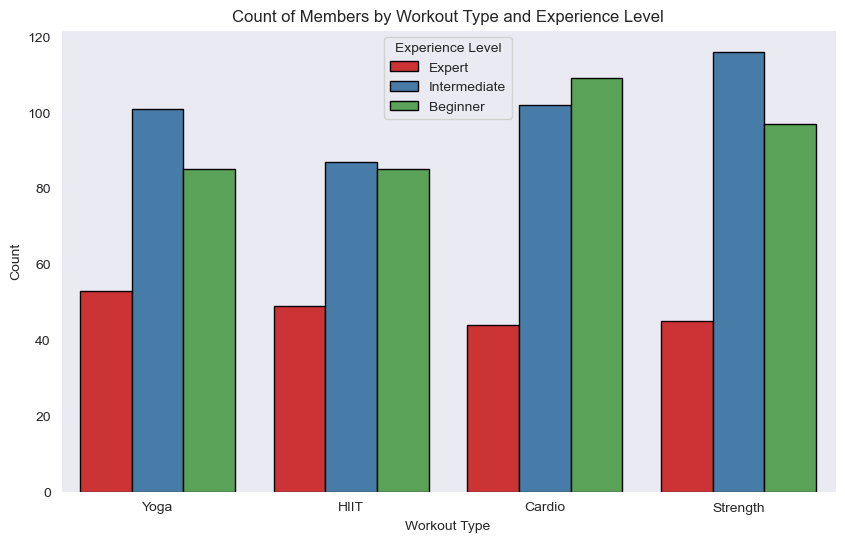

In [25]:
# different colors for beginner / intermediate / expert using pallette sets
sns.set_style("dark")  # darker background (from AI)

plt.figure(figsize=(10, 6)) # size of picture made bigger then rest due to many bars
sns.countplot(x="Workout Type", hue="Experience Level", data=gym, palette="Set1", edgecolor='black')

plt.title("Count of Members by Workout Type and Experience Level")
plt.xlabel("Workout Type")
plt.ylabel("Count")
plt.legend(title="Experience Level")
plt.show()


#### <span style="display:none">Histogram 1 - Distribution of session duration
>Histogram 1 - Distribution of session duration⬇️

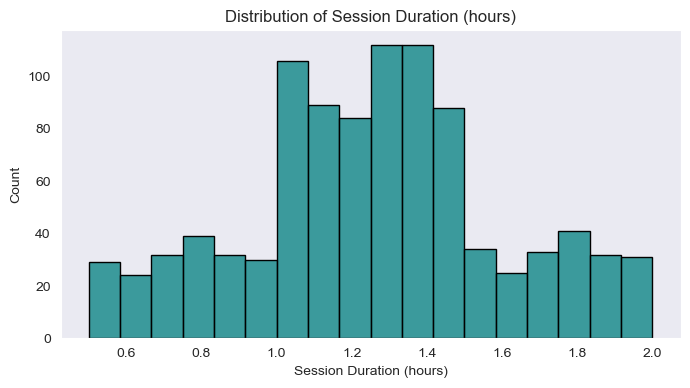

In [26]:
# Count = the number of peoples workout sessions that fall into each duration range
plt.figure(figsize=(8, 4))
sns.histplot(gym["Session Duration (hours)"], color='teal', edgecolor='black')
plt.title("Distribution of Session Duration (hours)")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Count")
plt.show()


#### <span style="display:none">Histogram 2 - Distribution of calories burned
>Histogram 2 - Distribution of calories burned⬇️

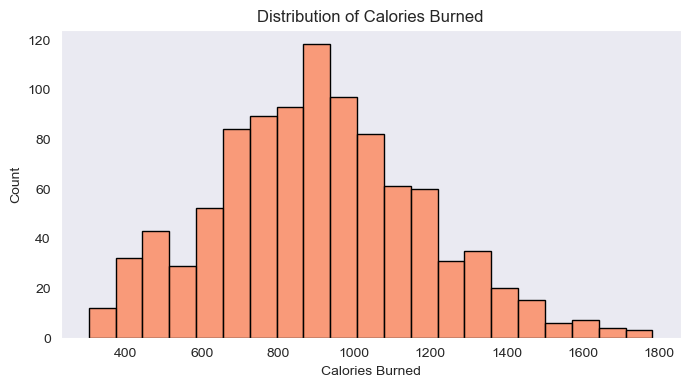

In [27]:
# Count = the number of peoples workout sessions that fall into each calories burned range
plt.figure(figsize=(8, 4))
sns.histplot(gym["Calories Burned"], color='coral', edgecolor='black')
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Count")
plt.show()


#### <span style="display:none"> Bar Plot 1 - Average calories burned by workout type
>Bar Plot 1 - Average calories burned by workout type⬇️

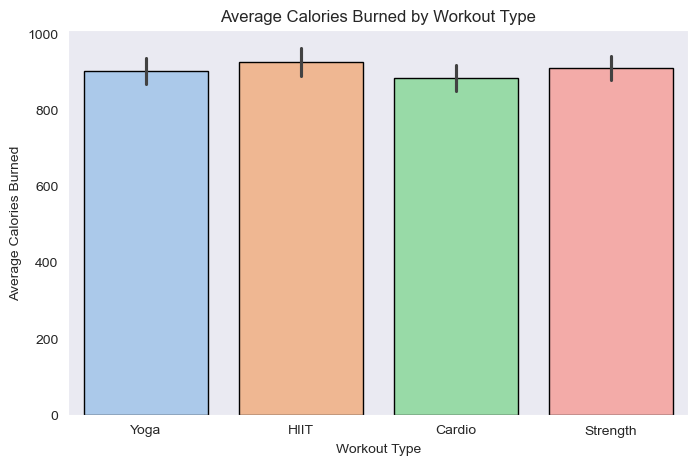

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Workout Type", y="Calories Burned", data=gym, palette='pastel', edgecolor="black", hue="Workout Type")
plt.title("Average Calories Burned by Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Average Calories Burned")
plt.show()


#### <span style="display:none">Bar Plot 2 - Average calories burned by workout type and gender
>Bar Plot 2 - Average calories burned by workout type and gender⬇️

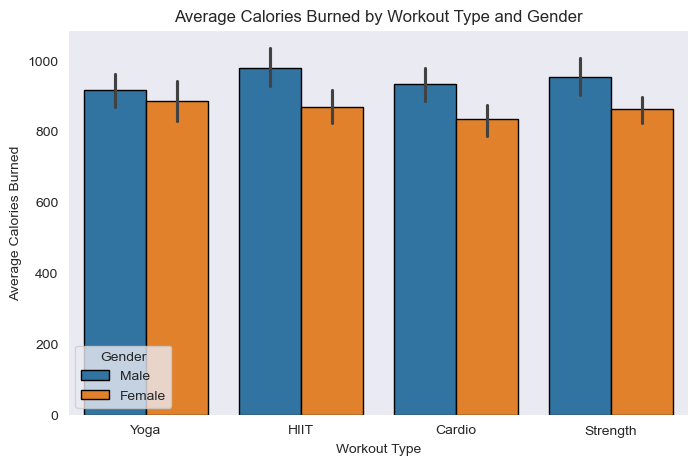

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Workout Type", y="Calories Burned", hue="Gender", data=gym, edgecolor='black')
plt.title("Average Calories Burned by Workout Type and Gender")
plt.xlabel("Workout Type")
plt.ylabel("Average Calories Burned")
plt.show()


#### <span style="display:none"> Bar Plot 3 - Average calories burned by experience level
>Bar Plot 3 - Average calories burned by experience level⬇️

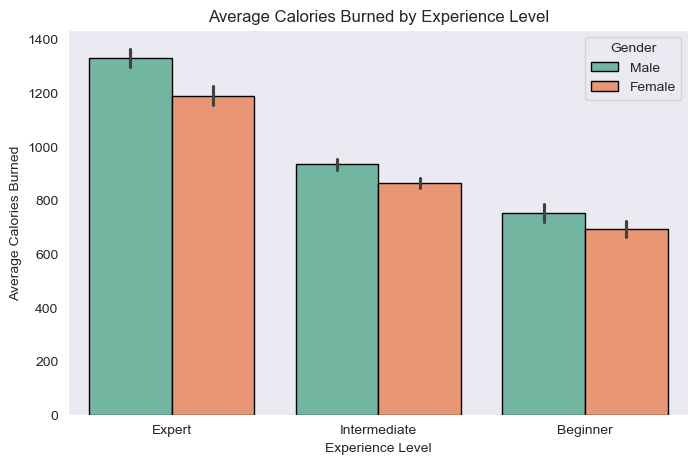

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Experience Level", y="Calories Burned", hue="Gender", data=gym, palette="Set2", estimator=np.mean, edgecolor='black')
plt.title("Average Calories Burned by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Calories Burned")
plt.show()


#### <span style="display:none">Scatter Plot - Session duration vs calories burned
>Scatter Plot - Session duration vs calories burned⬇️

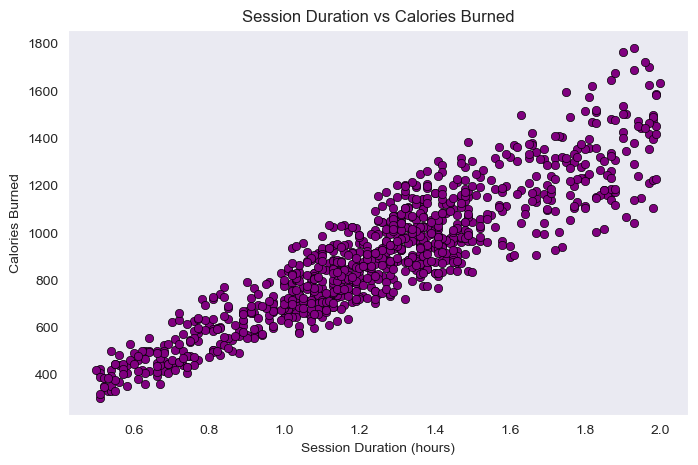

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Session Duration (hours)", y="Calories Burned", data=gym, color='purple', edgecolor='black')
plt.title("Session Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.show()


#### <span style="display:none">Regression Plot - Session duration vs calories burned
>Regression Plot - Session duration vs calories burned with custom regression line color⬇️

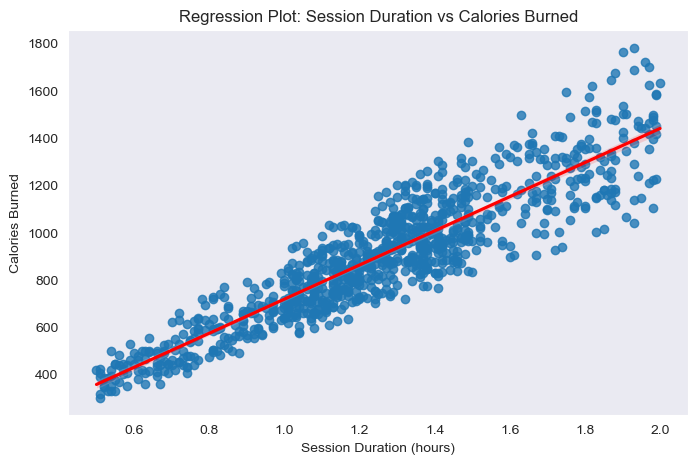

In [32]:
plt.figure(figsize=(8, 5))
sns.regplot(x="Session Duration (hours)", y="Calories Burned", data=gym, line_kws={"color": "red"}    # regression line color
)
plt.title("Regression Plot: Session Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.show()

#### <span style="display:none">Box Plot - Calories burned by workout type
>Boxplot - Calories burned by workout type⬇️

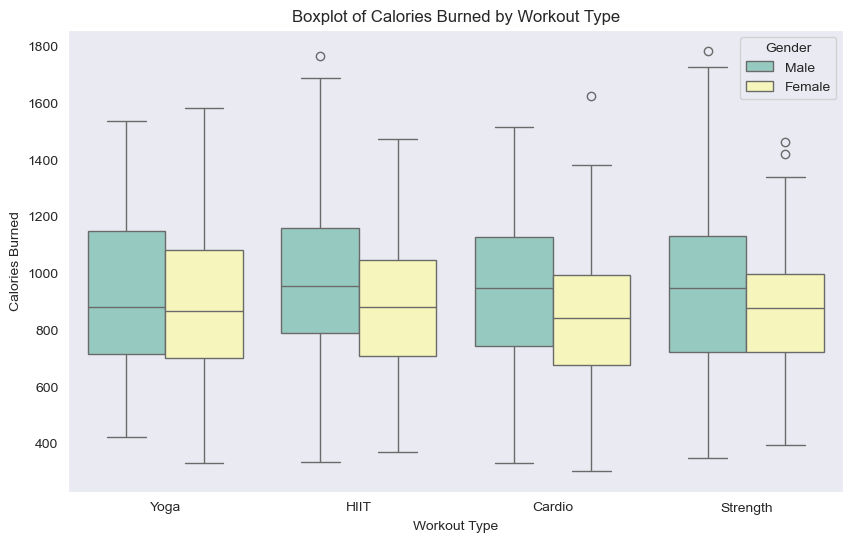

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Workout Type", y="Calories Burned", hue="Gender", data=gym, palette="Set3")
plt.title("Boxplot of Calories Burned by Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Calories Burned")
plt.show()


#### <span style="display:none">Heat Map - Numerical Variables
>Correlation Heatmap - Numerical variables⬇️

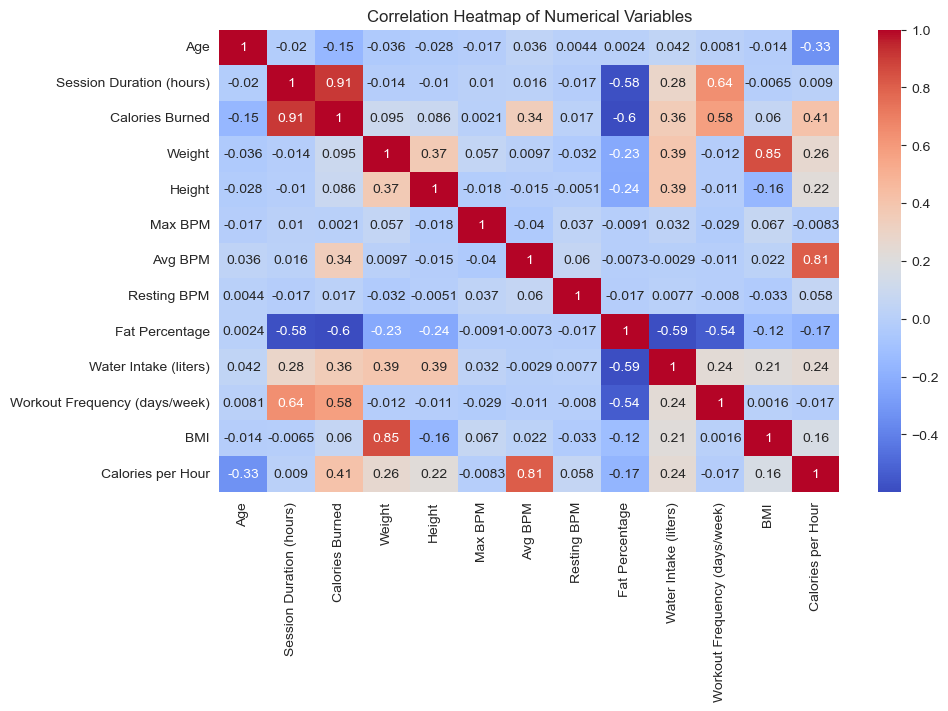

In [34]:
#genai
corr = gym.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


<small>

Summary of Visualizations

- Histograms show the distributions of session duration and calories burned across all gym members.

- Scatter + regression plot highlight the linear relationship between workout duration and calories burned.

- Bar charts compare average calories burned across workout types and genders.

- Countplot shows how frequently each workout type is performed across different experience levels.

- Boxplot reveals differences in the spread and consistency of calories burned across workout types.

- Heatmap summarizes correlations among numerical variables and supports identifying key relationships.

## **-------- Discussion --------**

Based on everything analyzed in tis project, there does seem to be a real relationship between how long people work out and how many calories they burn. This makes sense since the longer you exercise, the more energy you typically use. The data supported this, especially when looking at the visuals such as scatterplots and regression line. There were just a couple of points that didn’t fit the given pattern perfectly, but nothing overly extreme enough to change the overall trend.

Another interesting thing was that calories burned also seemed to connect to the type of workout and the person’s experience level. For example, HIIT and strength training tended to burn more calories compared to types like yoga, and expert gym members generally burned more than the beginner members. That suggests that efficiency and workout intensity both play a role, not just someone's time spent working out.

Even though the dataset was pretty detailed, there were still limitations. There are other factors given or not in the dataset that could influence calorie burn that weren’t measured here, like weight, fat percentage, diet, sleep, workout form, genetics, or whether people were actually pushing themselves during the session. With more variables, the analysis could go even deeper, for example, checking out how BMI or heart rate changes during a workout affects the calories burned. But for the scope of this assignment, focusing mainly on session duration and calories burned provided  some meaningful results.

Overall, the findings lined up well with common sense but also highlight that workout style and experience play a significant role almost as much as workout time. If someone wants to burn more calories, simply spending more time at the gym will help but choosing a higher intensity workout and gaining more experience could make an even bigger difference in the long run.

## **-------- GenAI Disclosure --------**


- List keywords to search up datasets im interested in sports and fitness specifically basketball
- Give a title, file name and draft an outline (accepeted all, gave breakdown of analyses section)
- What other counts could i do(came up with the grouped bin counts)
- How to change the regression line color in a Seaborn regplot
- Ideas for the EDA (top 10 highest, filter by experts, boolean indexing)
- Clarify what each visualization type was used for (histogram vs scatter vs barplot)
- I kept getting errors like: "Passing palette without assigning hue is deprecated and will be removed in v0.14.0. Assign the x variable to hue and set legend=False for the same effect." so i asked how to fix(told me what to assign hue variable to)
- How to create and interpret a Seaborn heatmap
- What styling Options exist for seaborn plots(themes, edges, sets, backgorund i.e dark)
- Whether to convert Experience Level numbers into text labels (Beginner / Intermediate / Expert)
- Whether indexing should start from Person 0 or Person 1, then decided to leave the default indexing
- How can i make text smaller(gave ">small<")
- Asked GenAI how to create hidden Markdown headers that appear in the VS Code outline(gave #### >span style="display:none"></span>)


## **-------- References --------**

1. https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset

2. https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python

3. https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax